In [2]:
from astropy.io import ascii
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


In [3]:
tbl_data = ascii.read(
    "../data/apjad382dt1_mrt.txt",
    format="cds"   
)

tbl_ids = pd.read_csv("../data/gaia_stream_id.csv", 
                      sep='\t')

print(tbl_data.colnames)
print(tbl_ids.columns)

tbl_ids[(tbl_ids['Name'] == 'Fjorm') | (tbl_ids['Name'] == 'Gjoll') | (tbl_ids['Name'] == 'Pal-5')]

['Gaia', 'RAdeg', 'DEdeg', 'plx', 'pmRA', 'pmDE', 'Gmag', '(B-R)', 'VHel', 'e_VHel', 'r_VHel', 'Stream']
Index(['s_ID', 'Name', 'Sample', 'alpha_0', 'alpha_pole', 'delta_pole', 'n',
       'n _v', 'M_sstarf', 'angl0[Fe/H]angr0', 'References', 'Remarks',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23'],
      dtype='object')


,s_ID,Name,Sample,alpha_0,alpha_pole,delta_pole,n,n _v,M_sstarf,angl0[Fe/H]angr0,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
33,34,Gjoll,1,154.403,158.539,43.545,607,40,2100,-1.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,47,Fjorm,1,189.867,103.086,19.455,297,29,1700,-2.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,61,Pal-5,1,229.022,320.298,-54.042,129,69,"17,000",-1.41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pal5: 129 stars
NGC3201: 607 stars
M68: 297 stars


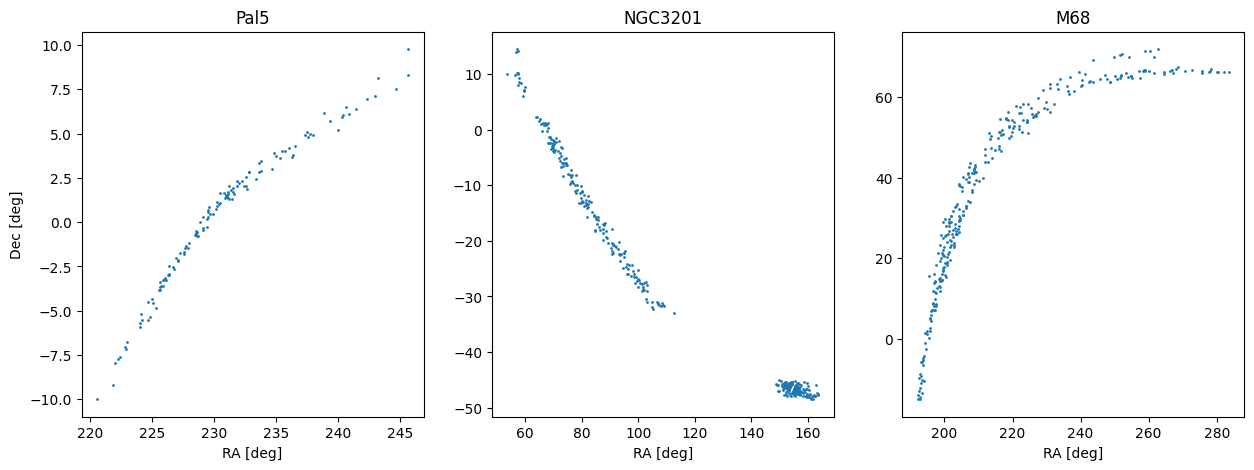

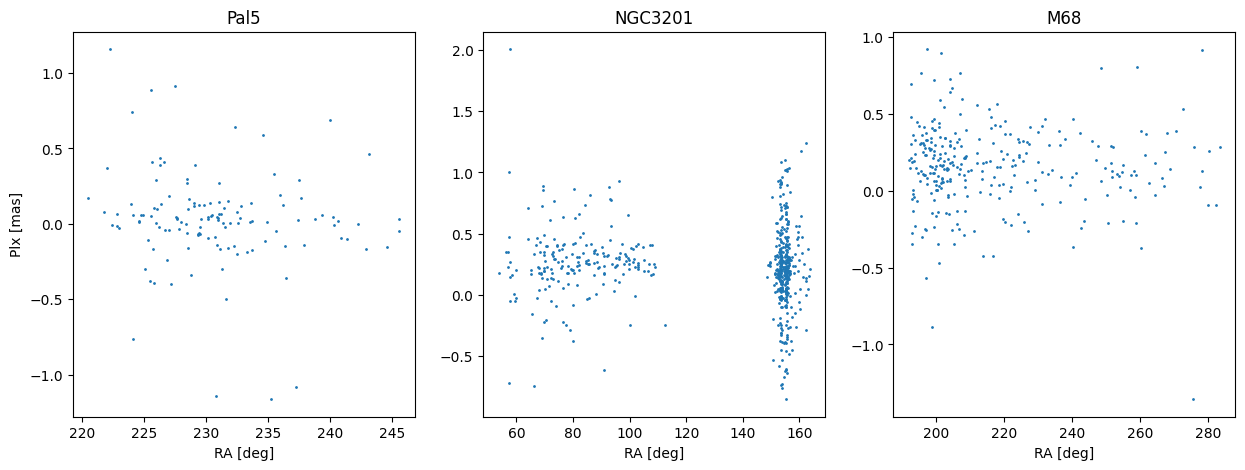

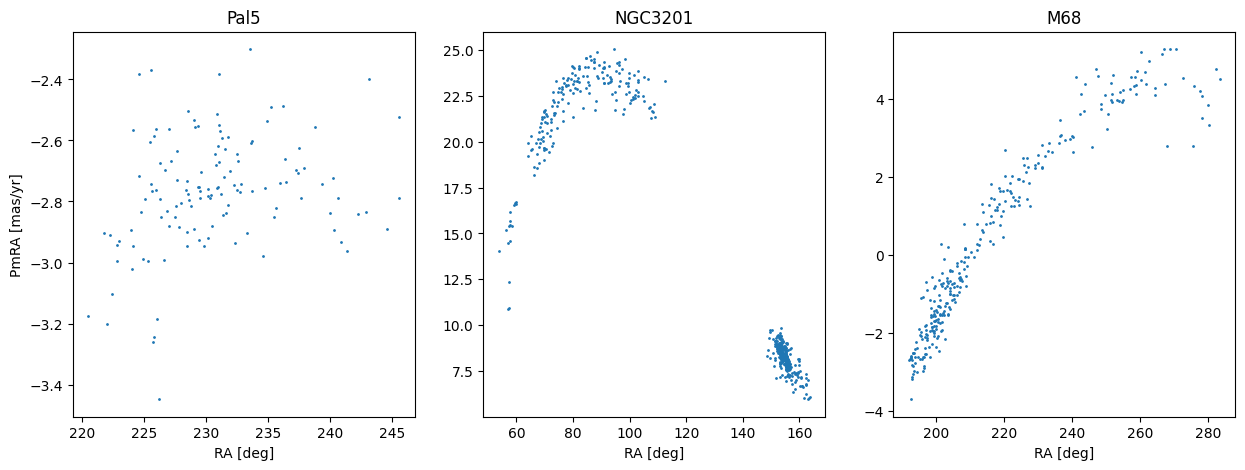

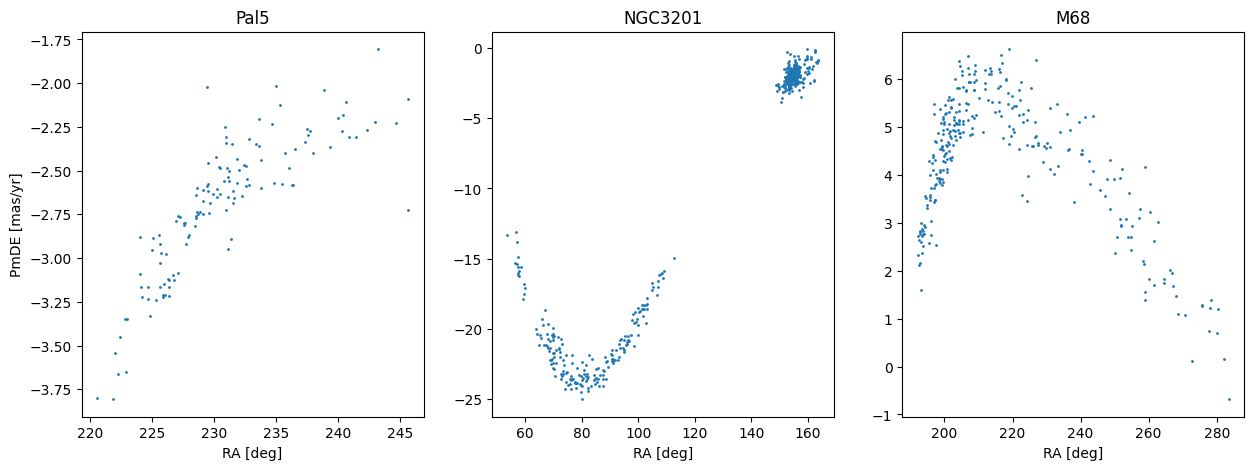

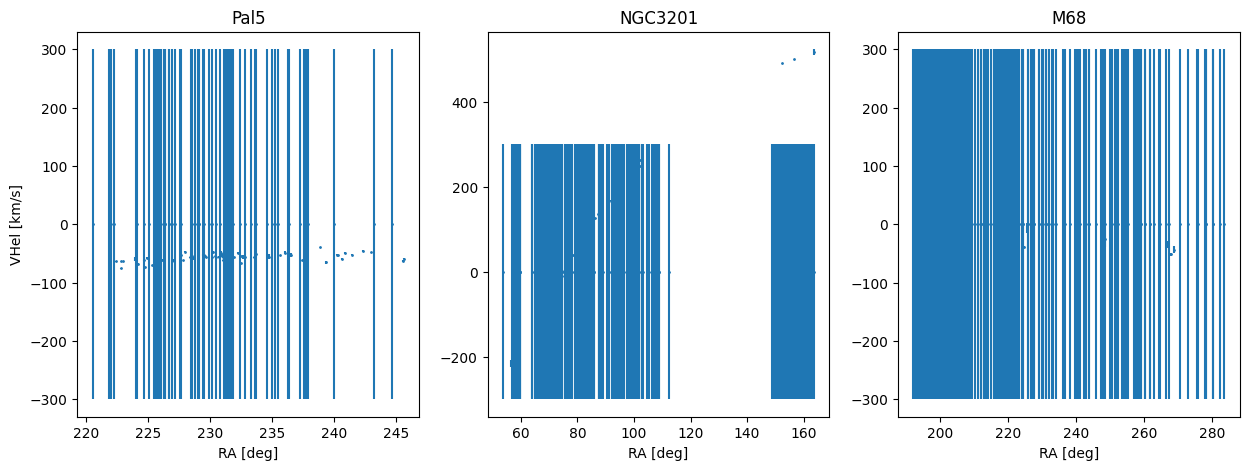

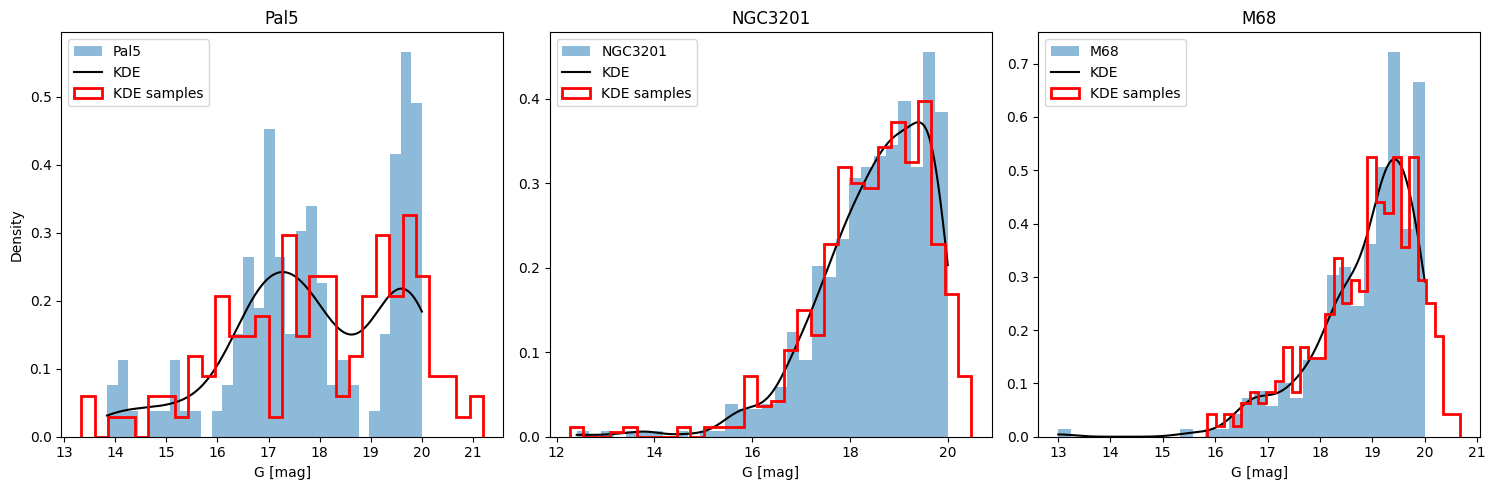

In [4]:
name_to_plot = ['Pal5', 'NGC3201', 'M68']
name_for_id = ['Pal-5', 'Gjoll', 'Fjorm']
particles = {}

for name_id, name_plot in zip(name_for_id, name_to_plot):
    source_id = tbl_ids.loc[tbl_ids['Name'] == name_id, 's_ID'].values[0]
    tbl_subset = tbl_data[tbl_data['Stream'] == source_id]
    print(f"{name_plot}: {len(tbl_subset)} stars")
    particles[name_plot] = {'Ra': np.array([a for a in tbl_subset['RAdeg']]),\
                            'Dec': np.array([a for a in tbl_subset['DEdeg']]),\
                            'Plx': np.array([a for a in tbl_subset['plx']]),\
                            'PmRA': np.array([a for a in tbl_subset['pmRA']]),\
                            'PmDE': np.array([a for a in tbl_subset['pmDE']]),\
                            'VHel': np.array([a for a in tbl_subset['VHel']]),\
                            'e_VHel': np.array([a for a in tbl_subset['e_VHel']]),\
                            'Gmag': np.array([a for a in tbl_subset['Gmag']]),\
                            }

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Dec [deg]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Plx [mas]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('PmRA [mas/yr]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('PmDE [mas/yr]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.errorbar(particles[name]['Ra'], particles[name]['VHel'], yerr=particles[name]['e_VHel'], fmt='o', markersize=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('VHel [km/s]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    data = particles[name]['Gmag']
    ax.hist(data, bins=30, label=name, alpha=0.5, density=True)
    # KDE
    kde = gaussian_kde(data)
    x_grid = np.linspace(np.min(data), np.max(data), 1_000)
    ax.plot(x_grid, kde(x_grid), color='k', label='KDE')
    samples = kde.resample((len(data*10), )).reshape(len(data))
    ax.hist(samples, bins=30, density=True, histtype='step', color='r', lw=2, label='KDE samples')
    ax.set_xlabel('G [mag]')
    if i == 0:
        ax.set_ylabel('Density')
    ax.set_title(name)
    ax.legend()
plt.tight_layout()